In [1]:
import pandas as pd
import scanpy as sc
from utils.io import read_anndata
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from dask import array as da
from tqdm.dask import TqdmCallback

from utils.io import read_anndata

adata = read_anndata(
    '/Volumes/Extreme SSD/BA_datasets/Wilson2022.h5ad',
    # X='X',
    obs='obs',
    var='var',
    obsm='obsm',
)

dask: False, backed: False
Read slot "obs", store as "obs"...


/Users/seohyon/miniconda3/envs/scanpy/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Read slot "var", store as "var"...
Read slot "obsm", store as "obsm"...


In [2]:
adata.obs["tissue"].unique()

['cortex of kidney']
Categories (1, object): ['cortex of kidney']

In [3]:
adata

AnnData object with n_obs × n_vars = 39176 × 35469
    obs: 'donor_id', 'self_reported_ethnicity_ontology_term_id', 'sample_uuid', 'sample_preservation_method', 'tissue_ontology_term_id', 'development_stage_ontology_term_id', 'suspension_uuid', 'suspension_type', 'library_uuid', 'assay_ontology_term_id', 'mapped_reference_annotation', 'is_primary_data', 'cell_type_ontology_term_id', 'author_cell_type', 'disease_ontology_term_id', 'reported_diseases', 'sex_ontology_term_id', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'percent.rpl', 'percent.rps', 'doublet_id', 'nCount_SCT', 'nFeature_SCT', 'seurat_clusters', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    obsm: 'X_harmony', 'X_pca', 'X_umap'

In [4]:
adata.obs["cell_type"].nunique()

13

In [5]:
adata.obs["donor_id"].nunique()

11

In [7]:
adata.obs["sample_uuid"].nunique()

11

In [8]:
adata.obs["library_uuid"].nunique()

11

In [9]:
adata.obs[["donor_id", "sample_uuid"]].drop_duplicates().value_counts("donor_id")

donor_id
control_1     1
control_2     1
control_3     1
diabetic_1    1
diabetic_2    1
diabetic_3    1
diabetic_4    1
diabetic_5    1
healthy_4     1
healthy_5     1
healthy_6     1
Name: count, dtype: int64

In [10]:
adata.obs[["donor_id", "sample_uuid"]].drop_duplicates().value_counts("sample_uuid")

sample_uuid
1ee72dd6-e794-4793-b58b-b763e3bf1fed    1
7605a4f4-e667-4418-85ec-c42e9ab8c761    1
8628f96c-2d97-4579-951c-044017ef6f0e    1
8949b21f-6f57-40c0-8f7b-0d6e9bff05cd    1
370769d1-96bd-4392-8ac4-56ab409e69a0    1
84824920-47bc-4929-b123-87574944aa37    1
c47a5959-a0ed-4276-8a8d-5f136f1edd29    1
d8b737fb-8a38-4a1d-a421-cbc81edddd05    1
d8149de2-123d-4852-a822-d8aee03b6266    1
e7372715-150e-4117-a11b-a88ea56ce5c5    1
f94a777a-0e6c-4361-a4ad-9472f69d46f3    1
Name: count, dtype: int64

In [12]:
adata.obs[["donor_id", "library_uuid"]].drop_duplicates().value_counts("library_uuid")

library_uuid
3e2de568-981f-4aae-8cd7-e8075dd89e76    1
82b6c04d-fea7-4ec2-8a75-7e32be7d55a6    1
84cce7e6-e630-498a-b4a9-3664b6cde8ad    1
89f2a9f6-25fc-4d0a-af0e-af393f20f7f1    1
374c3b1a-e9d1-44e9-8cfc-0ba0522d508e    1
364545f5-d190-4f2f-bae9-20fb11f39b3e    1
bbb332be-3eac-4a3f-ae93-c7851506ed70    1
bd366b10-adbf-45c4-b841-8a0a4f8f58b3    1
c4260338-5eb9-49e5-be2b-880f64912bf1    1
cccd2996-0f80-4b49-b210-86a55b800dd1    1
ea04b701-2b06-4f38-b6fd-706ed12a0750    1
Name: count, dtype: int64

In [13]:
adata.obs[["donor_id", "library_uuid"]].drop_duplicates().value_counts("donor_id")

donor_id
control_1     1
control_2     1
control_3     1
diabetic_1    1
diabetic_2    1
diabetic_3    1
diabetic_4    1
diabetic_5    1
healthy_4     1
healthy_5     1
healthy_6     1
Name: count, dtype: int64

In [14]:
batch_size = adata.obs["donor_id"].value_counts().sort_values(ascending=False)
mean = np.mean(batch_size)
std = np.std(batch_size)
min_val = batch_size.min()
max_val = batch_size.max()
print(f"Mean batch size: {mean:.2f}")
print(f"Standard deviation: {std:.2f}")
print(f"Minimum batch size: {min_val}")
print(f"Maximum batch size: {max_val}")
print(f"Coefficient of variance: {std/mean:.2f}")

Mean batch size: 3561.45
Standard deviation: 1933.67
Minimum batch size: 884
Maximum batch size: 8706
Coefficient of variance: 0.54


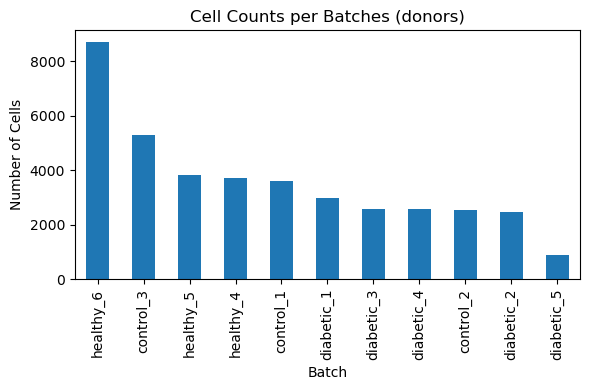

In [15]:
plt.figure(figsize=(6, 4))
batch_size.plot(kind='bar')
plt.title("Cell Counts per Batches (donors)")
plt.xlabel("Batch")
plt.ylabel("Number of Cells")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()